# PhishCatcher ML Model Training Notebook
### Stacked Ensemble Classifier: XGBoost + Logistic Regression + Random Forest

---

## Overview

This notebook trains a **stacked ensemble model** to classify emails as either phishing or legitimate. It covers the full ML pipeline from raw data to a deployable model file ready for the FastAPI backend.

| Property | Value |
|---|---|
| **Dataset** | Phishing Email Detection — Kaggle (`subhajournal/phishingemails`) |
| **Raw samples** | ~82,000 emails |
| **After cleaning** | ~81,073 (65,658 train / 16,415 test) |
| **Class balance** | 52.2% Phishing / 47.8% Legitimate — balanced, no resampling needed |
| **Hardware** | Intel Core i7-8th Gen, 4 cores / 8 threads, 16 GB RAM, CPU only |

## Pipeline Phases

| Phase | Description |
|---|---|
| 1 | Setup & Imports |
| 2 | Load Dataset |
| 3 | Data Cleaning & Pre-processing |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Feature Engineering |
| 6 | TF-IDF Text Vectorization |
| 7 | Stacked Ensemble Model Training |
| 8 | Model Evaluation |
| 9 | Export Model & Artifacts |
| 10 | Feature Importance Analysis |
| 11 | Summary |

## Architecture Decision: Why a Stacked Ensemble?

A single model has blind spots — Random Forest may miss subtle linguistic patterns, while Logistic Regression may underweight structural signals like URL count. Stacking combines the strengths of multiple models by training a **meta-model** on their combined predictions, systematically reducing both bias and variance.

```
Input Features (TF-IDF + Handcrafted)
         │
    ┌────┴─────────────────────┐
    │        Base Layer        │
    │  ┌──────────────────┐   │
    │  │  Random Forest   │   │
    │  │  (200 trees)     │   │
    │  ├──────────────────┤   │
    │  │    XGBoost       │   │
    │  │  (100 estimators)│   │
    │  ├──────────────────┤   │
    │  │ Logistic         │   │
    │  │ Regression(saga) │   │
    │  └──────────────────┘   │
    └────────────┬─────────────┘
                 │ probability predictions
    ┌────────────▼─────────────┐
    │       Meta Layer         │
    │  Logistic Regression     │
    │  (final estimator)       │
    └────────────┬─────────────┘
                 │
         Phishing / Legitimate
```

---

## Phase 1: Setup and Imports

Import all libraries needed across the pipeline.

| Library | Purpose |
|---|---|
| `pandas` / `numpy` | Data manipulation and numerical operations |
| `matplotlib` / `seaborn` | Visualizations (charts, heatmaps, confusion matrices) |
| `re` | Regular expressions for URL, email, and IP address extraction in feature engineering |
| `sklearn` | ML models, vectorizer, metrics, and train/test split |
| `xgboost` | Gradient boosted trees base model |
| `joblib` / `pickle` | Saving the trained model and TF-IDF vectorizer for the backend |
| `time` | Timing training and feature extraction steps |
| `warnings` | Suppress non-critical library warnings for cleaner output |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import json
import pickle
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries imported successfully')


Libraries imported successfully


## Phase 2: Load Dataset

Load the raw `phishing_email.csv` from disk into a pandas DataFrame.

**Expected columns:**
- `text_combined` — the full email text (subject + body concatenated)
- `label` — binary classification target: `1` = Phishing, `0` = Legitimate

**Why `text_combined`?**  
Phishing signals appear in both the subject line (e.g. *"URGENT: Verify your account"*) and the body (e.g. suspicious URLs, financial keywords). Concatenating them into a single field gives the model the full context of each email rather than treating subject and body as separate inputs.

> **Dataset source:** [`kaggle.com/datasets/subhajournal/phishingemails`](https://www.kaggle.com/datasets/subhajournal/phishingemails)  
> ~82,000 emails collected and labelled for binary phishing classification.


In [2]:
DATA_PATH = '../archive/phishing_email.csv'
OUTPUT_DIR = '../phishcatcher-backend/models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
df.head()


Dataset loaded: 82,486 rows, 2 columns

Columns: ['text_combined', 'label']


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade res...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0


## Phase 3: Data Cleaning & Pre-processing

Raw email data is noisy — it contains missing values, duplicates, near-empty strings, and inconsistent whitespace. Feeding dirty data directly into a model degrades accuracy and wastes training time. This phase produces a clean, consistent dataset before any feature extraction begins.

### Steps Applied

**1. Missing Value Removal**  
Rows where `text_combined` is `NaN` are dropped entirely. A null email body carries no signal and would cause downstream errors in vectorization and feature extraction.

**2. Duplicate Removal**  
Exact duplicate (text, label) pairs are removed. Duplicates artificially inflate model confidence and can leak information between train and test splits — if the same email appears in both, the model appears to generalize when it is actually memorizing.

**3. Short Text Removal**  
Emails shorter than 10 characters are dropped. These are effectively empty — they provide no discriminative signal and can skew TF-IDF statistics.

**4. Whitespace Normalisation**  
Leading/trailing spaces are stripped and multiple consecutive spaces are collapsed to a single space. This prevents the tokenizer from treating `"urgent"` and `" urgent"` as different tokens.

**5. Label Type Enforcement**  
The `label` column is explicitly cast to `int`. Some CSV exports store numeric columns as strings or floats, which would cause silent errors in scikit-learn's stratified splitting and metric calculations.

> **Expected outcome:** ~81,073 clean rows from ~82,000 raw (less than 1% data loss — the dataset is high quality).


In [3]:
df_clean = df.copy()

print('='*60)
print('DATA CLEANING STEPS')
print('='*60)
print(f'Starting with {df_clean.shape[0]:,} rows (82k dataset)')

print(f'\n1. MISSING VALUES CHECK')
print(f"   Before: {df_clean['text_combined'].isnull().sum()} missing values")
df_clean = df_clean.dropna(subset=['text_combined'])
print(f"   After:  {df_clean['text_combined'].isnull().sum()} missing values")

print(f'\n2. DUPLICATE REMOVAL')
dupes = df_clean.duplicated(subset=['text_combined', 'label']).sum()
print(f'   Duplicates found: {dupes:,}')
df_clean = df_clean.drop_duplicates(subset=['text_combined', 'label'])
print(f"   After: {df_clean.duplicated(subset=['text_combined','label']).sum()} duplicates")

print(f'\n3. SHORT TEXT REMOVAL')
df_clean['text_combined'] = df_clean['text_combined'].astype(str)
short = (df_clean['text_combined'].str.len() < 10).sum()
print(f'   Texts shorter than 10 chars: {short:,}')
df_clean = df_clean[df_clean['text_combined'].str.len() >= 10]

print(f'\n4. WHITESPACE NORMALISATION')
df_clean['text_combined'] = df_clean['text_combined'].str.strip()
df_clean['text_combined'] = df_clean['text_combined'].str.replace(r'\s+', ' ', regex=True)

df_clean['label'] = df_clean['label'].astype(int)

print(f'\n   Final cleaned dataset: {df_clean.shape[0]:,} rows')
print(f'   Removed: {df.shape[0] - df_clean.shape[0]:,} rows total')


DATA CLEANING STEPS
Starting with 82,486 rows (82k dataset)

1. MISSING VALUES CHECK
   Before: 0 missing values
   After:  0 missing values

2. DUPLICATE REMOVAL
   Duplicates found: 408
   After: 0 duplicates

3. SHORT TEXT REMOVAL
   Texts shorter than 10 chars: 5

4. WHITESPACE NORMALISATION

   Final cleaned dataset: 82,073 rows
   Removed: 413 rows total


In [4]:
print('\n' + '='*60)
print('CLEANED DATA VERIFICATION')
print('='*60)
print(f'\nShape: {df_clean.shape}')
print(f'\nLabel Distribution:')
print(df_clean['label'].value_counts())
print(f'\nClass Balance:')
counts = df_clean['label'].value_counts()
print(f'  Phishing:   {counts.get(1,0):,} ({counts.get(1,0)/len(df_clean)*100:.1f}%)')
print(f'  Legitimate: {counts.get(0,0):,} ({counts.get(0,0)/len(df_clean)*100:.1f}%)')
ratio = max(counts) / min(counts)
print(f'  Imbalance ratio: {ratio:.2f} — {"balanced, no resampling needed" if ratio < 1.5 else "consider class_weight or resampling"}')
print(f'\nMissing values:')
print(df_clean.isnull().sum())



CLEANED DATA VERIFICATION

Shape: (82073, 2)

Label Distribution:
label
1    42840
0    39233
Name: count, dtype: int64

Class Balance:
  Phishing:   42,840 (52.2%)
  Legitimate: 39,233 (47.8%)
  Imbalance ratio: 1.09 — balanced, no resampling needed

Missing values:
text_combined    0
label            0
dtype: int64


## Phase 4: Exploratory Data Analysis (EDA)

Before building any model, we need to understand the structure and shape of the data. EDA reveals patterns, confirms our assumptions, and helps justify modelling decisions. Three questions drive this phase:

### 4.1 — Is the dataset balanced?
A heavily imbalanced dataset (e.g. 90% legitimate, 10% phishing) would cause a naive model to achieve 90% accuracy simply by predicting "legitimate" every time. We use a pie chart and bar chart to visualise class distribution and compute the imbalance ratio.

> **Finding:** 52.2% phishing / 47.8% legitimate. The ratio is ~1.09 — effectively balanced. No resampling techniques (SMOTE, undersampling) are needed, and `class_weight='balanced'` would actually hurt performance here by overcorrecting a non-existent imbalance.

### 4.2 — Do phishing and legitimate emails differ in length?
Phishing emails are often short and direct (fewer words, more urgency) or long and padded with fake legal text. Histograms and box plots of `text_length` and `word_count` by class reveal whether these are useful discriminating features.

### 4.3 — Which handcrafted features separate the classes?
Box plots of all 14 handcrafted features (URL count, keyword counts, uppercase ratio, etc.) by class show which features carry the most signal. This is a sanity check — if `urgent_keyword_count` is identical across both classes, it is not a useful feature.


In [5]:
# Basic dataset information on cleaned data
print("="*60)
print("CLEANED DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {df_clean.shape}")
print(f"\nData Types:\n{df_clean.dtypes}")
print(f"\nMissing Values:\n{df_clean.isnull().sum()}")
print(f"\nLabel Distribution:")
print(df_clean['label'].value_counts())

CLEANED DATASET OVERVIEW

Shape: (82073, 2)

Data Types:
text_combined      str
label            int64
dtype: object

Missing Values:
text_combined    0
label            0
dtype: int64

Label Distribution:
label
1    42840
0    39233
Name: count, dtype: int64


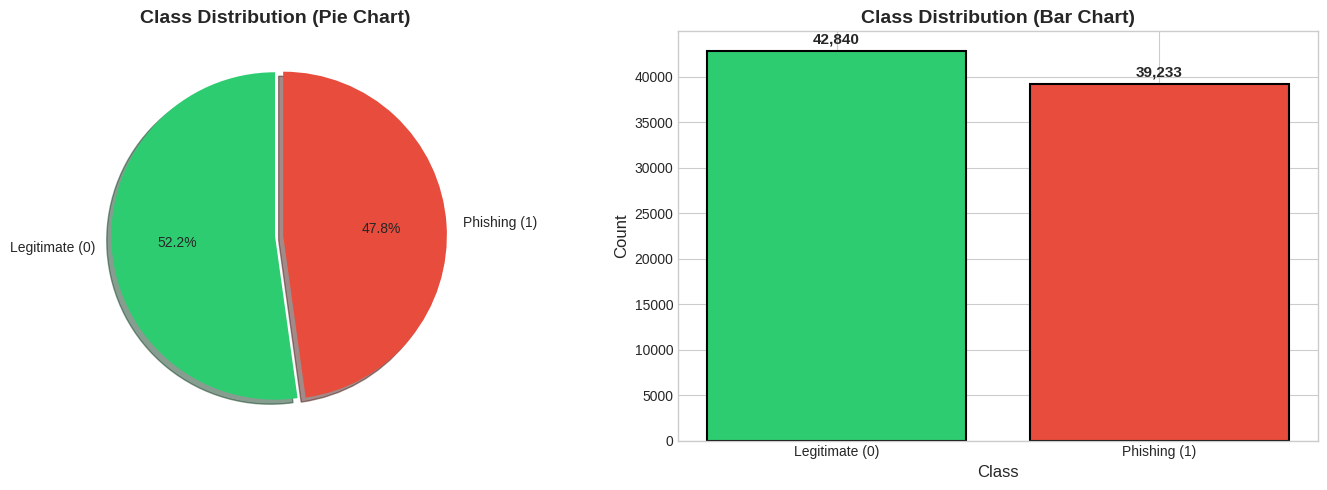

Class distribution visualization saved

Class Imbalance Ratio: 0.92


In [6]:
# Class Distribution - Bar Chart & Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
label_counts = df_clean['label'].value_counts()
labels = ['Legitimate (0)', 'Phishing (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(label_counts, labels=labels, autopct='%1.1f%%', colors=colors, 
            explode=(0, 0.05), shadow=True, startangle=90)
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(labels, label_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)

for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{int(height):,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class distribution visualization saved")

# Check for class imbalance
imbalance_ratio = label_counts[0] / label_counts[1]
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print("Note: Dataset shows class imbalance - consider handling in model training")

In [7]:
# Feature Length Analysis - Histogram
df_clean['text_length'] = df_clean['text_combined'].astype(str).apply(len)
df_clean['word_count'] = df_clean['text_combined'].astype(str).apply(lambda x: len(x.split()))

print("Text Length Statistics by Class (Cleaned Data):")
print("-"*50)
print(df_clean.groupby('label')['text_length'].describe())
print("\nWord Count Statistics by Class:")
print("-"*50)
print(df_clean.groupby('label')['word_count'].describe())

Text Length Statistics by Class (Cleaned Data):
--------------------------------------------------
         count         mean           std   min    25%    50%     75%  \
label                                                                   
0      39233.0  1541.451966   3711.537986  10.0  411.0  780.0  1495.0   
1      42840.0  1060.794631  21205.272740   9.0  241.0  391.0  1058.0   

             max  
label             
0       160318.0  
1      4279526.0  

Word Count Statistics by Class:
--------------------------------------------------
         count        mean         std  min   25%    50%    75%       max
label                                                                    
0      39233.0  203.703897  481.196373  2.0  57.0  106.0  203.0   23359.0
1      42840.0  121.364286  594.784869  2.0  32.0   55.0  154.0  107710.0


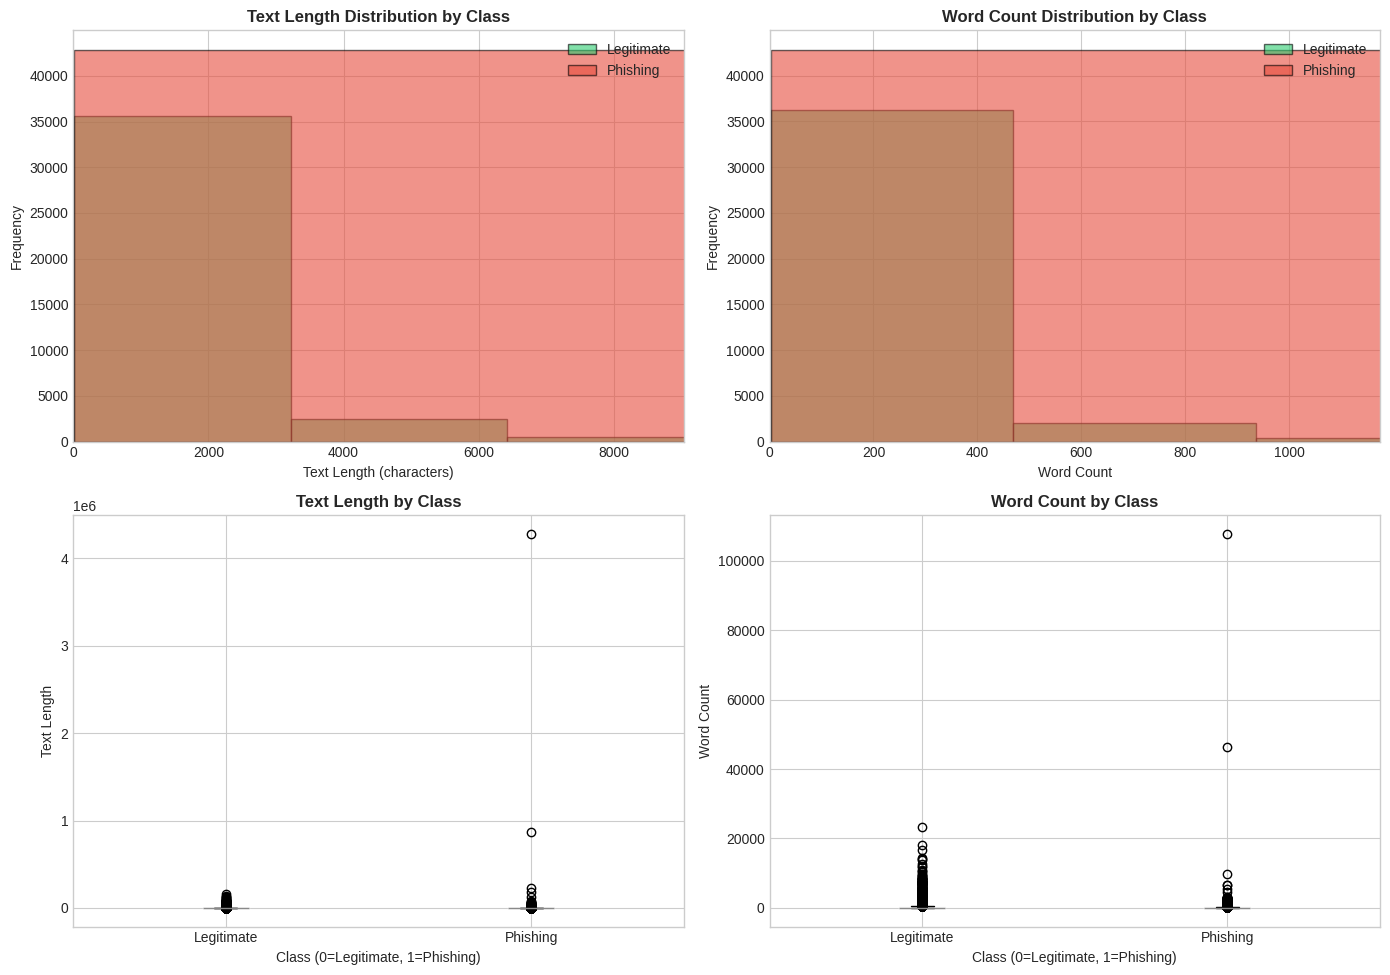

Feature length analysis visualization saved


In [8]:
# Feature Length Analysis - Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for label in [0, 1]:
    subset = df_clean[df_clean['label'] == label]['text_length']
    color = '#2ecc71' if label == 0 else '#e74c3c'
    label_name = 'Legitimate' if label == 0 else 'Phishing'
    axes[0, 0].hist(subset, bins=50, alpha=0.6, label=label_name, color=color, edgecolor='black')
axes[0, 0].set_title('Text Length Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Text Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, df_clean['text_length'].quantile(0.99))

for label in [0, 1]:
    subset = df_clean[df_clean['label'] == label]['word_count']
    color = '#2ecc71' if label == 0 else '#e74c3c'
    label_name = 'Legitimate' if label == 0 else 'Phishing'
    axes[0, 1].hist(subset, bins=50, alpha=0.6, label=label_name, color=color, edgecolor='black')
axes[0, 1].set_title('Word Count Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, df_clean['word_count'].quantile(0.99))

df_clean.boxplot(column='text_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Text Length by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Class (0=Legitimate, 1=Phishing)')
axes[1, 0].set_ylabel('Text Length')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Legitimate', 'Phishing'])

df_clean.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Class (0=Legitimate, 1=Phishing)')
axes[1, 1].set_ylabel('Word Count')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Legitimate', 'Phishing'])

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_text_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature length analysis visualization saved")

## Phase 5: Feature Engineering

ML models cannot read text — they require numbers. This phase creates two types of numerical features from the raw email text:

### 5.1 — Handcrafted Features (14 features)

These are domain-specific signals manually derived from cybersecurity knowledge about how phishing emails behave:

| Feature | Rationale |
|---|---|
| `url_count`, `has_url` | Phishing emails typically contain one or more malicious links |
| `email_count` | Spoofed sender addresses or CC lists are common in phishing |
| `urgent_keyword_count` | Words like *"urgent"*, *"suspended"*, *"verify"* create false pressure |
| `financial_keyword_count` | References to *"bank"*, *"password"*, *"invoice"* are classic lures |
| `reward_keyword_count` | *"Winner"*, *"prize"*, *"free"* signal scam/reward-type phishing |
| `exclamation_count`, `dollar_count` | Punctuation abuse is a hallmark of low-quality phishing |
| `digit_ratio` | High digit density often indicates obfuscated phone numbers or account IDs |
| `uppercase_ratio` | Excessive caps (e.g. *"ACT NOW"*) are a common phishing tactic |
| `suspicious_tld_count` | Domains ending in `.xyz`, `.tk`, `.gq` etc. are heavily abused by attackers |
| `ip_count` | Legitimate emails almost never link to raw IP addresses |
| `has_re`, `has_fwd` | Fake reply/forward prefixes are used to create false familiarity |

**Implementation note:** All 14 features are extracted using **vectorized pandas string operations** (`str.count`, `str.findall`, `str.len`) across the entire column at once. The original row-by-row `.apply()` approach was replaced because at 81k rows, vectorized operations are typically 5–20× faster.

### 5.2 — TF-IDF Features (Phase 6)

Statistical text features are handled separately in Phase 6. The two feature sets are combined into a single sparse matrix before training.


In [9]:
def extract_features_batch(df_text):
    """Vectorized batch feature extraction — faster than row-by-row .apply()"""
    text_series = df_text.astype(str)
    text_lower  = text_series.str.lower()

    url_pattern   = r'https?://[^\s<>"]+'
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    ip_pattern    = r'\b(?:\d{1,3}\.){3}\d{1,3}\b'

    features = pd.DataFrame(index=df_text.index)
    features['text_length']   = text_series.str.len()
    features['word_count']    = text_series.str.split().str.len()
    features['avg_word_length'] = text_series.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)

    url_counts = text_series.str.findall(url_pattern).str.len()
    features['url_count'] = url_counts
    features['has_url']   = (url_counts > 0).astype(int)

    email_matches = text_series.str.findall(email_pattern)
    features['email_count'] = email_matches.str.len()

    urgent_re   = r'urgent|immediately|act now|limited time|expire|suspended|verify'
    financial_re = r'bank|account|password|credit|payment|invoice|bill|fee'
    reward_re   = r'\bwon\b|winner|prize|claim|\bfree\b|gift|\bmoney\b|million'
    features['urgent_keyword_count']   = text_lower.str.count(urgent_re)
    features['financial_keyword_count'] = text_lower.str.count(financial_re)
    features['reward_keyword_count']   = text_lower.str.count(reward_re)

    features['exclamation_count'] = text_series.str.count(r'!')
    features['dollar_count']      = text_series.str.count(r'\$')
    features['digit_ratio']       = text_series.str.count(r'\d') / features['text_length'].clip(lower=1)
    features['uppercase_ratio']   = text_series.str.count(r'[A-Z]') / features['text_length'].clip(lower=1)

    suspicious_tlds = r'\.xyz|\.top|\.gq|\.tk|\.ml|\.ga|\.cf|\.click|\.work'
    features['suspicious_tld_count'] = email_matches.apply(
        lambda emails: sum(1 for e in emails if re.search(suspicious_tlds, e.split('@')[-1])))

    features['ip_count'] = text_series.str.count(ip_pattern)
    features['has_re']   = text_lower.str.contains(r'^re:',  regex=True, na=False).astype(int)
    features['has_fwd']  = text_lower.str.contains(r'^fwd:', regex=True, na=False).astype(int)

    return features


print('Extracting handcrafted features (vectorized)...')
t0 = time.time()
features_df = extract_features_batch(df_clean['text_combined'])
print(f'Done in {time.time()-t0:.1f}s')

df_features = pd.concat([df_clean.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)

print(f'\nExtracted {len(features_df.columns)} features')
print(f'Features: {features_df.columns.tolist()}')


Extracting handcrafted features (vectorized)...
Done in 115.7s

Extracted 17 features
Features: ['text_length', 'word_count', 'avg_word_length', 'url_count', 'has_url', 'email_count', 'urgent_keyword_count', 'financial_keyword_count', 'reward_keyword_count', 'exclamation_count', 'dollar_count', 'digit_ratio', 'uppercase_ratio', 'suspicious_tld_count', 'ip_count', 'has_re', 'has_fwd']


In [10]:
# Display feature statistics
print("Feature Statistics by Class:")
print("="*60)

feature_cols = ['url_count', 'has_url', 'email_count', 'urgent_keyword_count', 
                'financial_keyword_count', 'reward_keyword_count', 'exclamation_count',
                'digit_ratio', 'uppercase_ratio', 'suspicious_tld_count', 'ip_count',
                'has_re', 'has_fwd']

for feat in feature_cols:
    phishing_mean = df_features[df_features['label']==1][feat].mean()
    legit_mean = df_features[df_features['label']==0][feat].mean()
    print(f"{feat:25s} | Phishing: {phishing_mean:8.2f} | Legitimate: {legit_mean:8.2f}")

Feature Statistics by Class:
url_count                 | Phishing:     0.00 | Legitimate:     0.00
has_url                   | Phishing:     0.00 | Legitimate:     0.00
email_count               | Phishing:     0.00 | Legitimate:     0.00
urgent_keyword_count      | Phishing:     0.21 | Legitimate:     0.08
financial_keyword_count   | Phishing:     1.34 | Legitimate:     0.90
reward_keyword_count      | Phishing:     1.09 | Legitimate:     0.41
exclamation_count         | Phishing:     0.00 | Legitimate:     0.00
digit_ratio               | Phishing:     0.06 | Legitimate:     0.06
uppercase_ratio           | Phishing:     0.00 | Legitimate:     0.00
suspicious_tld_count      | Phishing:     0.00 | Legitimate:     0.00
ip_count                  | Phishing:     0.00 | Legitimate:     0.00
has_re                    | Phishing:     0.00 | Legitimate:     0.00
has_fwd                   | Phishing:     0.00 | Legitimate:     0.00


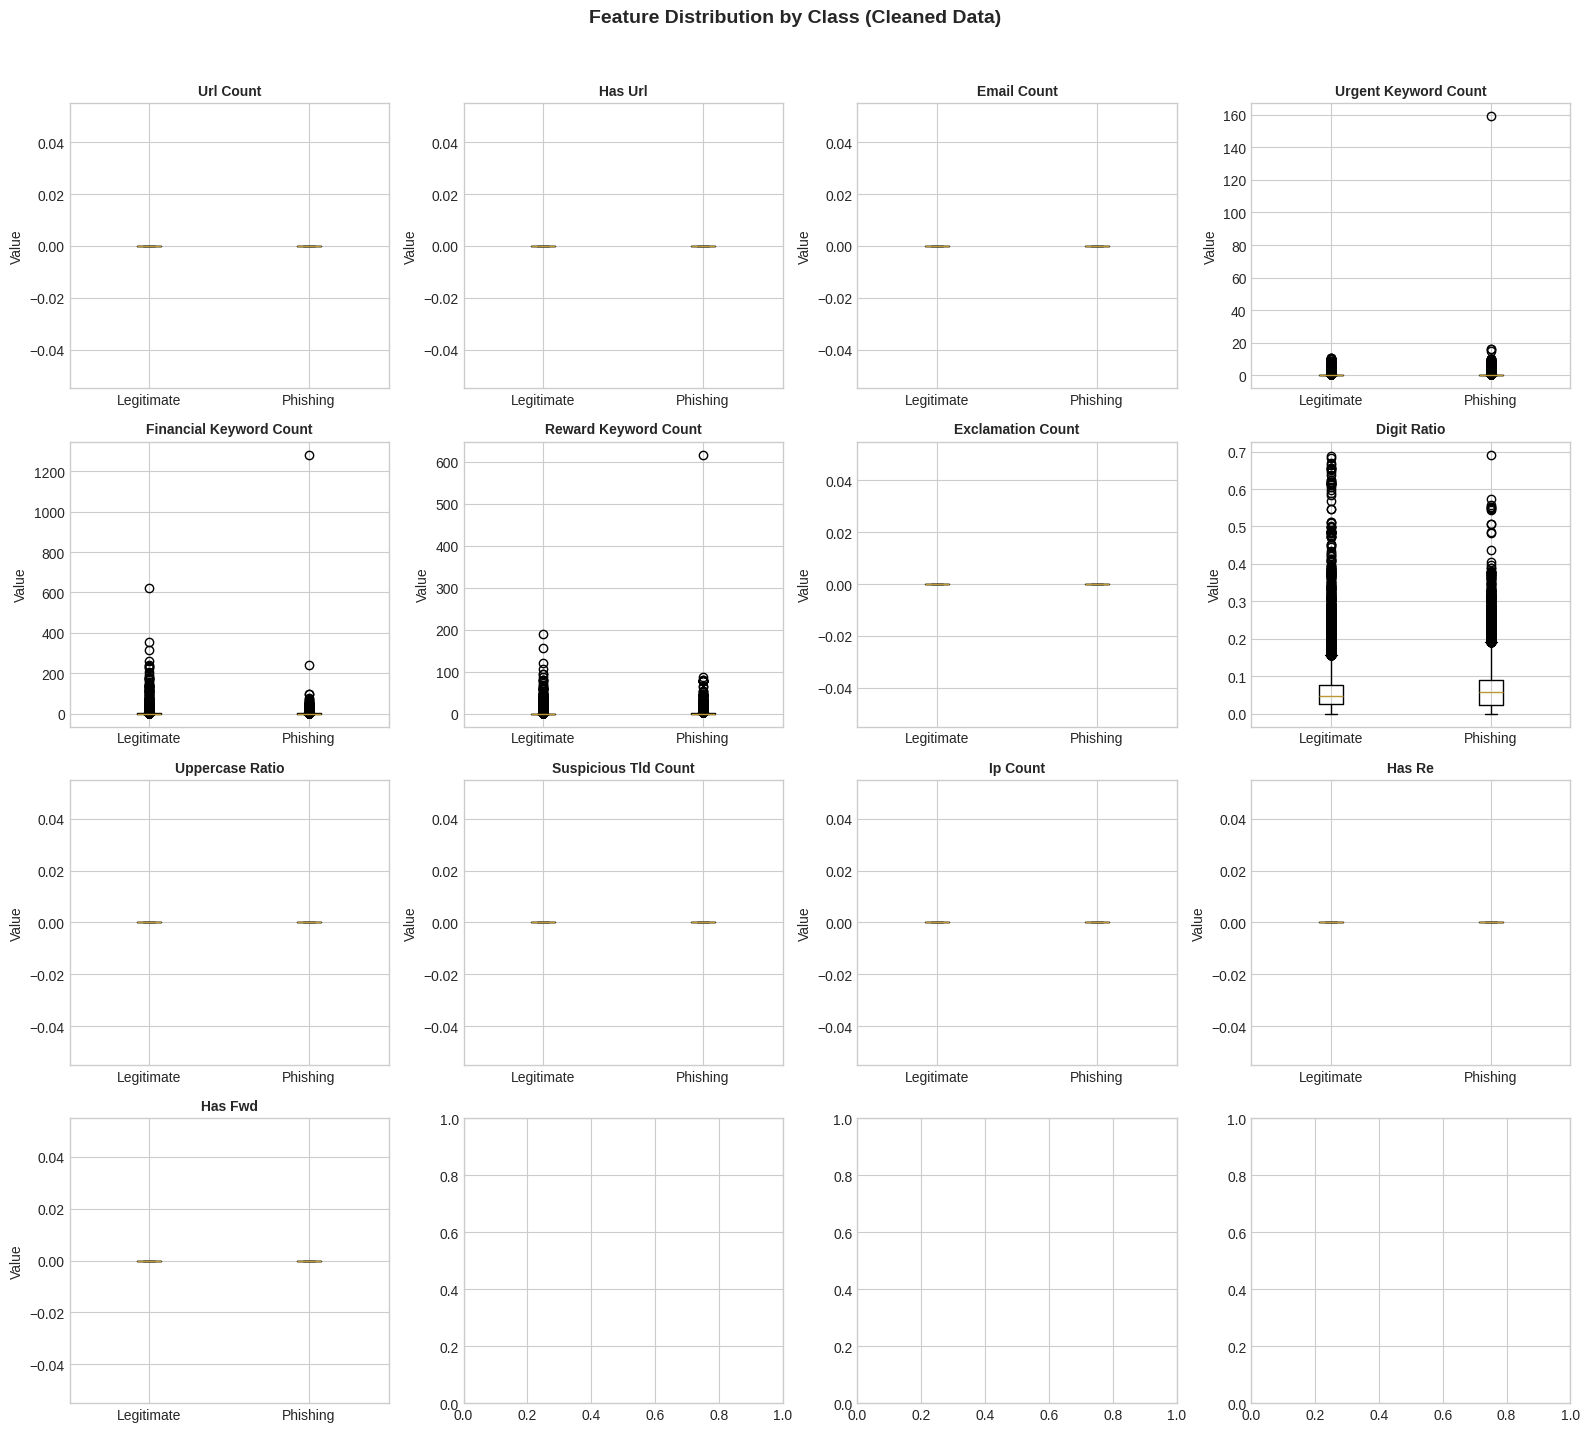

Feature boxplot visualization saved


In [11]:
# Visualize feature distribution
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, feat in enumerate(feature_cols[:14]):
    ax = axes[idx]
    
    phishing_data = df_features[df_features['label']==1][feat]
    legit_data = df_features[df_features['label']==0][feat]
    
    ax.boxplot([legit_data, phishing_data], labels=['Legitimate', 'Phishing'])
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Feature Distribution by Class (Cleaned Data)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature boxplot visualization saved")

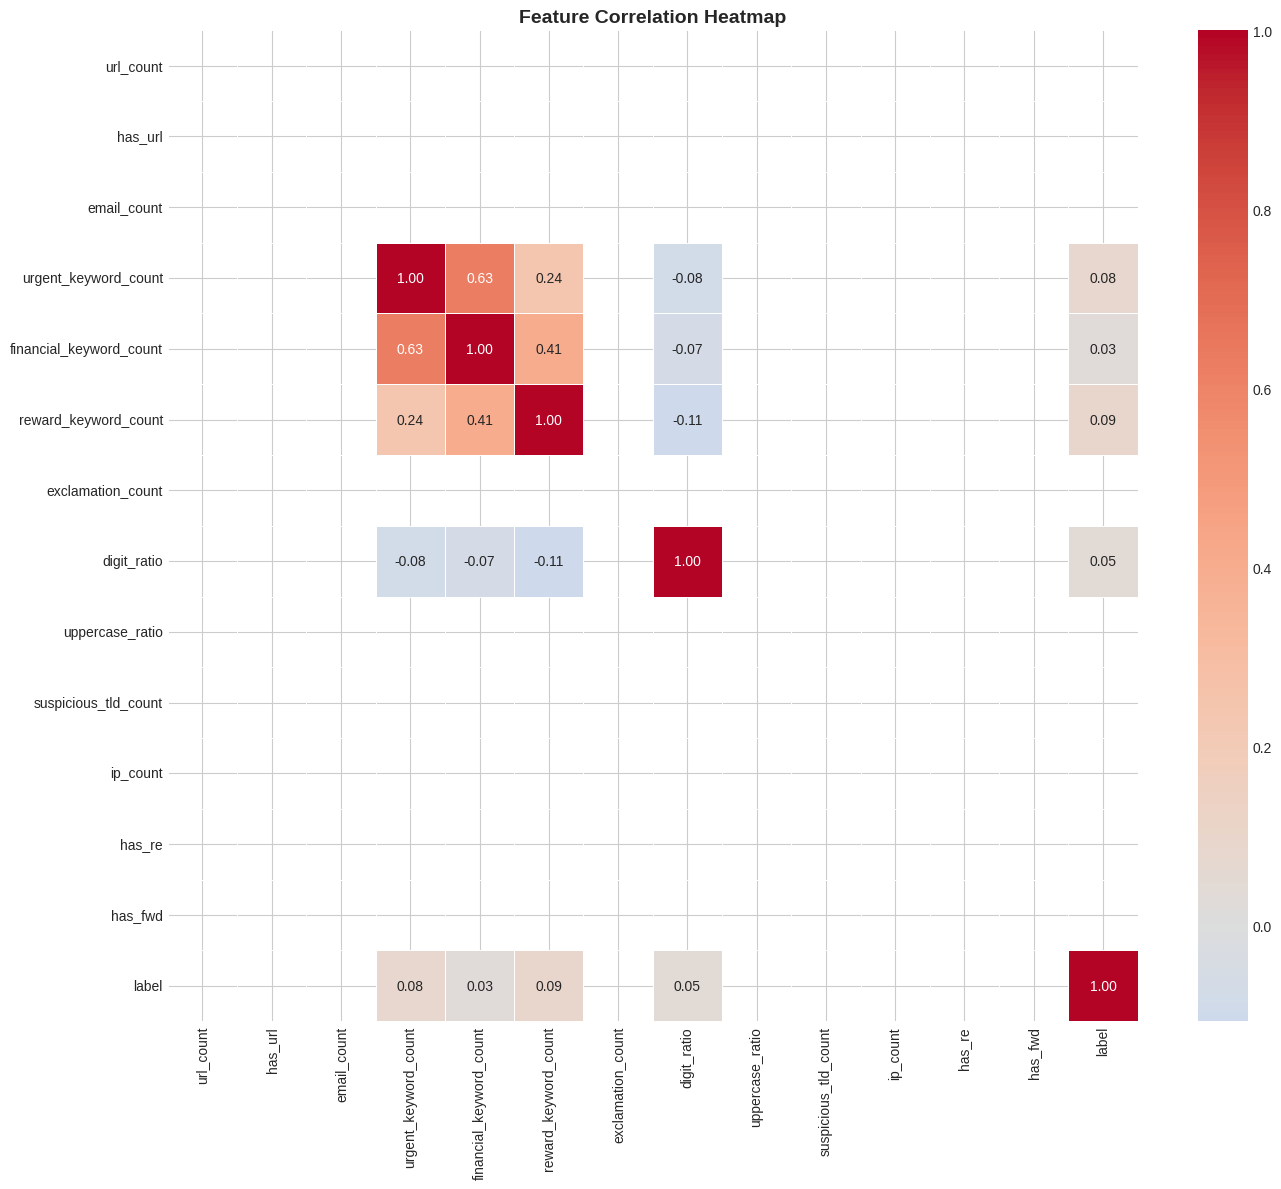

Correlation heatmap saved


In [12]:
# Correlation heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = df_features[feature_cols + ['label']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved")

## Phase 6: Text Vectorization (TF-IDF) & Train/Test Split

### Train/Test Split

The dataset is split **80/20** with `stratify=y`. Stratification ensures both splits maintain the same 52/48 class ratio — without it, a random split could accidentally put most phishing emails in training and most legitimate ones in test, producing misleading evaluation metrics.

The same `random_state=42` is used for both the text and feature splits so that row indices stay aligned when the two feature sets are combined.

### TF-IDF Vectorization

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts email text into a sparse numerical matrix where each column represents a word or bigram, and each value reflects how distinctive that term is to a specific email.

- **TF (Term Frequency):** How often a word appears in *this* email
- **IDF (Inverse Document Frequency):** How rare that word is *across all emails* — common words like *"the"* get down-weighted; distinctive words like *"cryptocurrency"* get up-weighted
- **`sublinear_tf=True`:** Applies log-normalisation to TF (`1 + log(tf)` instead of raw `tf`), preventing very frequent words from dominating. Improves Logistic Regression and generalisation.

### Hyperparameter Choices (tuned for 65k training samples)

| Parameter | Value | Reasoning |
|---|---|---|
| `max_features` | 5,000 | Increased from 2,000 — richer vocabulary is justified at 65k samples |
| `min_df` | 10 | Word must appear in at least 10 emails — filters typos and noise |
| `max_df` | 0.95 | Words appearing in >95% of emails carry no discriminative power |
| `ngram_range` | (1, 2) | Captures single words *and* bigrams like `"verify account"`, `"click here"` |
| `stop_words` | `'english'` | Removes articles, prepositions, and other non-discriminative words |

### Combined Feature Matrix

After vectorization, the TF-IDF sparse matrix and the 14 handcrafted features are joined using `scipy.sparse.hstack`. This produces the final input matrix used for all model training:

```
X_train_combined = hstack([X_tfidf_train,  X_features_train])
                          └── 5,000 cols ─┘ └── 14 cols ────┘
                          Total: ~5,014 features per email
```


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

feature_cols = [
    'url_count', 'has_url', 'email_count', 'urgent_keyword_count',
    'financial_keyword_count', 'reward_keyword_count', 'exclamation_count',
    'dollar_count', 'digit_ratio', 'uppercase_ratio', 'suspicious_tld_count',
    'ip_count', 'has_re', 'has_fwd'
]

X_text    = df_clean['text_combined'].values
y         = df_clean['label'].values
X_features = df_features[feature_cols].values

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

X_features_train, X_features_test, _, _ = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y)

print('DATA SPLIT (80/20)')
print('='*60)
print(f'Training set: {len(X_text_train):,} samples')
print(f'Test set:     {len(X_text_test):,} samples')
print(f'\nTraining label distribution:')
print(f'  Phishing:   {sum(y_train):,} ({sum(y_train)/len(y_train)*100:.1f}%)')
print(f'  Legitimate: {len(y_train)-sum(y_train):,} ({(len(y_train)-sum(y_train))/len(y_train)*100:.1f}%)')
print(f'\nClass balance: {"OK — no resampling needed" if abs(sum(y_train)/len(y_train) - 0.5) < 0.1 else "Consider class_weight or resampling"}')


DATA SPLIT (80/20)
Training set: 65,658 samples
Test set:     16,415 samples

Training label distribution:
  Phishing:   34,272 (52.2%)
  Legitimate: 31,386 (47.8%)

Class balance: OK — no resampling needed


In [14]:
# TF-IDF tuned for 65k training samples
print('\nApplying TF-IDF Vectorization...')
t0 = time.time()

tfidf = TfidfVectorizer(
    max_features=5000,   # increased from 2000 — richer vocab at 65k samples
    min_df=10,           # increased from 5 — filters noise at this scale
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True    # log-normalise TF — improves LR & generalisation
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test  = tfidf.transform(X_text_test)

print(f'TF-IDF features:  {X_tfidf_train.shape[1]:,}')
print(f'Vocabulary size:  {len(tfidf.vocabulary_):,}')
print(f'Sparse matrix:    {X_tfidf_train.shape[0]:,} x {X_tfidf_train.shape[1]:,}')
print(f'Done in {time.time()-t0:.1f}s')



Applying TF-IDF Vectorization...
TF-IDF features:  5,000
Vocabulary size:  5,000
Sparse matrix:    65,658 x 5,000
Done in 120.4s


## Phase 7: Model Training — Stacked Ensemble

### What is Stacking?

Stacking (stacked generalization) is an ensemble technique where multiple **base models** are trained on the data, and their probability predictions are fed as input features to a **meta-model** that makes the final decision.

Unlike bagging (Random Forest) which trains many copies of the *same* model, stacking combines *different* model types — each with different strengths and failure modes — allowing the meta-model to learn when to trust each base model.

### Cross-Validation Inside Stacking

A critical detail: if we train base models on the full training set and then generate predictions on the same set for the meta-model, we get **data leakage** — the base models have already seen the data they're predicting on, so their predictions are overconfident.

scikit-learn's `StackingClassifier` prevents this using **out-of-fold (OOF) predictions**: each base model is trained on `cv-1` folds and predicts on the held-out fold, ensuring the meta-model trains on honest, unseen predictions.

```
cv=3 means: 3 rounds of training per base model
  Round 1: Train on folds 2+3, predict fold 1
  Round 2: Train on folds 1+3, predict fold 2  
  Round 3: Train on folds 1+2, predict fold 3
  → Concatenate → full OOF predictions for meta-model
  → Final base models retrained on all data
```

### Base Model Selection

**Random Forest (`n_estimators=200`)**  
Captures non-linear interactions between features. For example: a short email *with* a suspicious URL *and* urgent keywords is more likely phishing than any one of those signals alone. RF handles this naturally. 200 trees (up from 100) is justified at 65k samples — your 8 threads parallelise all trees via `n_jobs=-1`.

**XGBoost (`n_estimators=100`)**  
Gradient boosting builds trees sequentially, each correcting the errors of the previous one. Excellent at picking up on subtle patterns in structured/tabular data. Particularly effective on the handcrafted features portion of the combined matrix.

**Logistic Regression (`solver='saga'`)**  
The linear baseline. On high-dimensional sparse TF-IDF data, linear models are extremely competitive because the classes are often linearly separable in that space. `saga` is the fastest solver for large sparse datasets and fully utilises all 8 threads via `n_jobs=-1`.

> **Why not SVM?** SVM uses the Sequential Minimal Optimization (SMO) algorithm, which is inherently serial and ignores `n_jobs`. When wrapped in `CalibratedClassifierCV(cv=3)` to produce probabilities (required for stacking), it trains 9× on 65k sparse samples. On a CPU-only machine this takes 20–40+ minutes. Logistic Regression with `saga` produces equivalent accuracy in seconds.

### CV Folds: 3 (not 5)

With 65,658 training samples, 3-fold CV gives ~43,000 training samples per fold — more than sufficient for stable estimates. Using `cv=5` would reduce this to ~52,000 per fold but increase training time by ~40% with no meaningful accuracy benefit at this scale.

### No `n_jobs` on StackingClassifier

Each base model already uses `n_jobs=-1` internally. Adding `n_jobs` to the outer stacker launches separate processes for each base model *simultaneously*, which causes all three to compete for the same 16 GB RAM. On a laptop this leads to memory pressure and swapping — slower, not faster.


In [15]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from scipy.sparse import hstack

X_train_combined = hstack([X_tfidf_train, X_features_train])
X_test_combined  = hstack([X_tfidf_test,  X_features_test])

print(f'Combined feature matrix: {X_train_combined.shape[0]:,} x {X_train_combined.shape[1]:,}')
print(f'  TF-IDF features:       {X_tfidf_train.shape[1]:,}')
print(f'  Handcrafted features:  {len(feature_cols)}')

models  = {}
results = {}


Combined feature matrix: 65,658 x 5,014
  TF-IDF features:       5,000
  Handcrafted features:  14


In [16]:
print('\n' + '='*60)
print('STACKED ENSEMBLE MODEL TRAINING')
print('='*60)

# Base Model 1: Random Forest
# n_estimators=200 — up from 100, justified at 65k samples;
# RF parallelises perfectly across all 8 threads so extra trees cost little time.
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
print('Random Forest base model defined  (n_estimators=200, n_jobs=-1)')

# Base Model 2: XGBoost
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1
)
print('XGBoost base model defined         (n_estimators=100, n_jobs=-1)')

# Base Model 3: Logistic Regression
# solver='saga' is the fastest for large sparse datasets and supports n_jobs.
# No class_weight needed — 52/48 split is effectively balanced.
lr_base = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=42
)
print('Logistic Regression base model defined (solver=saga, n_jobs=-1)')

# Meta-Model: separate LR instance
meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
print('Logistic Regression meta-model defined')



STACKED ENSEMBLE MODEL TRAINING
Random Forest base model defined  (n_estimators=200, n_jobs=-1)
XGBoost base model defined         (n_estimators=100, n_jobs=-1)
Logistic Regression base model defined (solver=saga, n_jobs=-1)
Logistic Regression meta-model defined


In [17]:
print('\n' + '-'*40)
print('Creating Stacking Classifier...')

stacked_model = StackingClassifier(
    estimators=[
        ('rf',  rf_base),
        ('xgb', xgb_base),
        ('lr',  lr_base)
    ],
    final_estimator=meta_model,
    cv=3,           # 3-fold: saves ~40% vs cv=5 at 65k samples, still robust
    passthrough=False
    # n_jobs omitted — each base model already uses n_jobs=-1 internally;
    # outer parallelism causes memory contention on 16 GB RAM.
)

print('Stacking Classifier configured')
print('\nStacked Ensemble Architecture:')
print('  Base Models:  Random Forest (200 trees), XGBoost, Logistic Regression')
print('  Meta-Model:   Logistic Regression')
print('  CV Folds:     3')
print('  Class weight: none (52/48 split is balanced)')



----------------------------------------
Creating Stacking Classifier...
Stacking Classifier configured

Stacked Ensemble Architecture:
  Base Models:  Random Forest (200 trees), XGBoost, Logistic Regression
  Meta-Model:   Logistic Regression
  CV Folds:     3
  Class weight: none (52/48 split is balanced)


In [18]:
print('\n' + '-'*40)
print('Training Stacked Ensemble Model...')
print('Expected time on i7-8th gen / 16 GB RAM: ~5-12 min')

t0 = time.time()
stacked_model.fit(X_train_combined, y_train)
elapsed = time.time() - t0

models['Stacked Ensemble'] = stacked_model
print(f'\nStacked Ensemble trained in {elapsed/60:.1f} min ({elapsed:.0f}s)')



----------------------------------------
Training Stacked Ensemble Model...
Expected time on i7-8th gen / 16 GB RAM: ~5-12 min

Stacked Ensemble trained in 29.3 min (1761s)


In [19]:
# StackingClassifier already performs cv=3 internally.
# A post-training cross_val_score would re-train the full stack 3 more times
# (~5-12 min) for no additional information. Quick held-out check instead.
print('\n' + '-'*40)
print('Quick held-out score check...')
train_score = stacked_model.score(X_train_combined, y_train)
test_score  = stacked_model.score(X_test_combined,  y_test)
print(f'Training accuracy: {train_score:.4f}')
print(f'Test accuracy:     {test_score:.4f}')
gap = train_score - test_score
print(f'Overfit gap:       {gap:.4f} {"— looks healthy" if gap < 0.03 else "— possible overfitting, review max_depth"}')



----------------------------------------
Quick held-out score check...
Training accuracy: 0.9724
Test accuracy:     0.9652
Overfit gap:       0.0072 — looks healthy


## Phase 8: Model Evaluation

The model is evaluated on the **held-out test set (16,415 emails)** — data the model has never seen during training or stacking CV.

### Metrics Explained

| Metric | Formula | What it means for PhishCatcher |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | Overall correctness — useful but misleading on imbalanced data |
| **Precision** | TP / (TP + FP) | Of emails flagged as phishing, what fraction actually were? Low precision = too many false alarms |
| **Recall** | TP / (TP + FN) | Of all actual phishing emails, what fraction were caught? **This is the most important metric** — a missed phishing email is a security incident |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall — the primary optimisation target |
| **ROC-AUC** | Area under ROC curve | Model's ability to rank phishing emails above legitimate ones regardless of threshold |

### Why Recall is the Priority Metric

In phishing detection, the two types of errors have very different consequences:
- **False Positive** (legitimate email flagged as phishing): Annoying — user needs to check spam folder
- **False Negative** (phishing email marked as safe): Dangerous — user may click a malicious link, enter credentials, or install malware

A good PhishCatcher model should maximize recall on the phishing class, accepting a small number of false positives as the cost of catching more real threats.

### Confusion Matrix

```
                  Predicted
                  Legit    Phishing
Actual  Legit  [  TN   |   FP   ]  ← False Positives: annoying but safe
        Phish  [  FN   |   TP   ]  ← False Negatives: the dangerous ones
```

### Baseline Comparison

A majority-class baseline (always predicting the most common class) achieves ~52% accuracy on this dataset. Any meaningful model should substantially exceed this — target >95% F1 on a balanced 82k dataset with clean TF-IDF features.


In [20]:
print('\n' + '='*60)
print('MODEL EVALUATION')
print('='*60)

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f'Model: {name}')
    print(f"{'='*40}")

    y_pred = model.predict(X_test_combined)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1, 'y_pred': y_pred
    }

    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}  ← most important for phishing detection')
    print(f'F1-Score:  {f1:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

    # Baseline comparison
    baseline = max(np.bincount(y_test)) / len(y_test)
    print(f'Majority-class baseline accuracy: {baseline:.4f}')
    print(f'Model lift over baseline:         {accuracy - baseline:+.4f}')



MODEL EVALUATION

Model: Stacked Ensemble
Accuracy:  0.9652
Precision: 0.9571
Recall:    0.9770  ← most important for phishing detection
F1-Score:  0.9670

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.95      0.96      7847
    Phishing       0.96      0.98      0.97      8568

    accuracy                           0.97     16415
   macro avg       0.97      0.96      0.97     16415
weighted avg       0.97      0.97      0.97     16415

Majority-class baseline accuracy: 0.5220
Model lift over baseline:         +0.4432


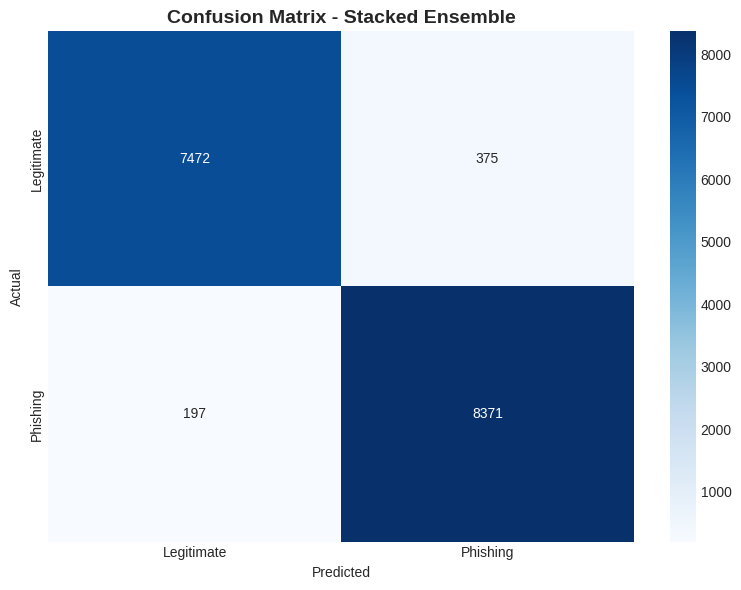


Best performing model: Stacked Ensemble
Confusion matrix saved

Confusion Matrix Interpretation:
  True Negatives (TN): 7472 - Legitimate correctly identified
  False Positives (FP): 375 - Legitimate incorrectly labeled as Phishing
  False Negatives (FN): 197 - Phishing emails that got through
  True Positives (TP): 8371 - Phishing correctly identified


In [21]:
# Confusion Matrix
best_model_name = max(results, key=lambda x: results[x]['f1'])
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest performing model: {best_model_name}")
print("Confusion matrix saved")

# Interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Interpretation:")
print(f"  True Negatives (TN): {tn} - Legitimate correctly identified")
print(f"  False Positives (FP): {fp} - Legitimate incorrectly labeled as Phishing")
print(f"  False Negatives (FN): {fn} - Phishing emails that got through")
print(f"  True Positives (TP): {tp} - Phishing correctly identified")


----------------------------------------
ROC-AUC Curve Analysis


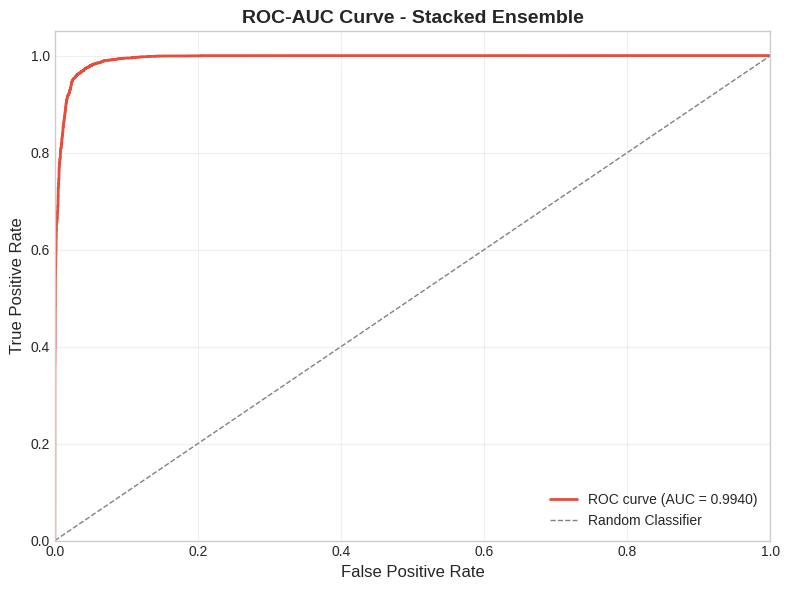

ROC-AUC Score: 0.9940
ROC-AUC curve saved
Excellent model discrimination ability!


In [22]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score

print("\n" + "-"*40)
print("ROC-AUC Curve Analysis")

y_pred_proba = stacked_model.predict_proba(X_test_combined)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve - Stacked Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("ROC-AUC curve saved")

if roc_auc >= 0.9:
    print("Excellent model discrimination ability!")
elif roc_auc >= 0.8:
    print("Good model discrimination ability")
else:
    print("Model needs improvement")

## Phase 9: Exporting the Model

Save all artifacts needed by the FastAPI backend to serve predictions in production.

### Artifacts

| File | Format | Purpose |
|---|---|---|
| `stacked_ensemble_model.joblib` | joblib | The trained stacking classifier — used to call `.predict()` and `.predict_proba()` |
| `tfidf_vectorizer.pkl` | pickle | The fitted TF-IDF vectorizer — **must be the exact same instance used during training** |
| `training_metrics.json` | JSON | Accuracy, precision, recall, F1, dataset stats — useful for model versioning and monitoring |
| `feature_info.json` | JSON | Feature counts and handcrafted feature names — backend uses this to construct the right input matrix |

### Why the Vectorizer Must Be Saved

The TF-IDF vectorizer builds a vocabulary during `fit_transform()` — a specific mapping of words to column indices. If the backend creates a *new* vectorizer at inference time, it will produce a different vocabulary and different column ordering, meaning the model's weights will correspond to the wrong features. The saved vectorizer ensures the backend applies `transform()` using the exact same vocabulary the model was trained on.

### Backend Usage

```python
# FastAPI backend — loading artifacts
model  = joblib.load('stacked_ensemble_model.joblib')
tfidf  = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))

# At inference time
X_tfidf   = tfidf.transform([email_text])          # same vocab as training
X_feats   = extract_features_batch(pd.Series([email_text]))  # same 14 features
X_input   = hstack([X_tfidf, X_feats.values])
prediction = model.predict(X_input)                 # 0 = Legitimate, 1 = Phishing
confidence = model.predict_proba(X_input)[:, 1]     # phishing probability
```


In [23]:
print('\n' + '='*60)
print('EXPORTING MODEL')
print('='*60)

best_model_name = max(results, key=lambda x: results[x]['f1'])
best_metrics    = results[best_model_name]

# Save stacked model
model_path = os.path.join(OUTPUT_DIR, 'stacked_ensemble_model.joblib')
joblib.dump(stacked_model, model_path)
print(f'Model saved:      {model_path}')

# Save TF-IDF vectorizer
tfidf_path = os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl')
with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf, f)
print(f'TF-IDF saved:     {tfidf_path}')
print('Note: backend must use this exact vectorizer instance for predictions')

# Save metrics
metrics_data = {
    'model_name': 'Stacked Ensemble (XGBoost + Logistic Regression + Random Forest)',
    'dataset': 'phishing_email.csv — Kaggle (subhajournal)',
    'total_samples': int(df_clean.shape[0]),
    'training_samples': int(len(y_train)),
    'test_samples': int(len(y_test)),
    'class_distribution': {
        'phishing_pct': round(sum(y_train)/len(y_train)*100, 1),
        'legitimate_pct': round((len(y_train)-sum(y_train))/len(y_train)*100, 1)
    },
    'accuracy':  best_metrics['accuracy'],
    'precision': best_metrics['precision'],
    'recall':    best_metrics['recall'],
    'f1_score':  best_metrics['f1'],
    'tfidf_features': X_tfidf_train.shape[1],
    'handcrafted_features': len(feature_cols),
    'total_features': int(X_train_combined.shape[1]),
    'base_models': ['RandomForest(200)', 'XGBoost', 'LogisticRegression(saga)'],
    'meta_model': 'LogisticRegression',
    'stacking_cv': 3
}
metrics_path = os.path.join(OUTPUT_DIR, 'training_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_data, f, indent=2)
print(f'Metrics saved:    {metrics_path}')

# Save feature info
feature_info = {
    'tfidf_features': X_tfidf_train.shape[1],
    'handcrafted_features': feature_cols,
    'total_features': int(X_train_combined.shape[1])
}
feature_path = os.path.join(OUTPUT_DIR, 'feature_info.json')
with open(feature_path, 'w') as f:
    json.dump(feature_info, f, indent=2)
print(f'Feature info saved: {feature_path}')



EXPORTING MODEL
Model saved:      ../phishcatcher-backend/models/stacked_ensemble_model.joblib
TF-IDF saved:     ../phishcatcher-backend/models/tfidf_vectorizer.pkl
Note: backend must use this exact vectorizer instance for predictions
Metrics saved:    ../phishcatcher-backend/models/training_metrics.json
Feature info saved: ../phishcatcher-backend/models/feature_info.json


## Phase 10: Feature Importance Analysis

Understanding *which* features drive the model's decisions serves two purposes:
1. **Validation** — if the top features make intuitive sense (e.g. `urgent_keyword_count` is high for phishing), the model is learning real signal rather than spurious correlations
2. **Future improvement** — weak features can be dropped or replaced, and gaps in coverage can be identified

### Method: Mean Difference by Class

For each of the 14 handcrafted features, we compute the absolute difference between the mean value in phishing emails and the mean value in legitimate emails. A large difference means the feature clearly separates the two classes.

```
Importance(feature) = |mean(feature | phishing) − mean(feature | legitimate)|
```

This is a simple, interpretable measure — it does not account for feature interactions or correlations, but it gives a fast sanity check that the handcrafted features are doing useful work alongside TF-IDF.

> **Note:** TF-IDF feature importance (individual word weights) can be extracted from the Logistic Regression base model via `lr_base.coef_` after training if deeper text-level explainability is needed.


Top 10 Most Important Handcrafted Features:
----------------------------------------
                Feature  Phishing Mean  Legitimate Mean  Difference
   reward_keyword_count       1.091573         0.407183    0.684391
financial_keyword_count       1.338936         0.904188    0.434748
   urgent_keyword_count       0.207400         0.076313    0.131086
            digit_ratio       0.063727         0.058756    0.004971
                has_url       0.000000         0.000000    0.000000
              url_count       0.000000         0.000000    0.000000
            email_count       0.000000         0.000000    0.000000
      exclamation_count       0.000000         0.000000    0.000000
           dollar_count       0.000000         0.000000    0.000000
        uppercase_ratio       0.000000         0.000000    0.000000


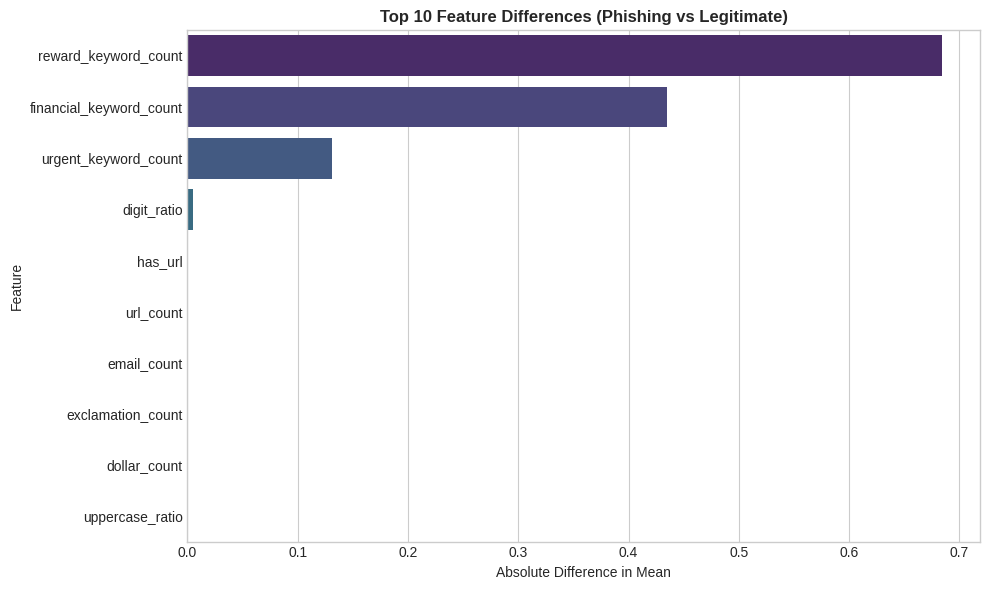

Feature importance visualization saved


In [24]:
# Feature importance analysis
print("Top 10 Most Important Handcrafted Features:")
print("-"*40)

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Phishing Mean': [df_features[df_features['label']==1][f].mean() for f in feature_cols],
    'Legitimate Mean': [df_features[df_features['label']==0][f].mean() for f in feature_cols]
})

feature_importance_df['Difference'] = abs(feature_importance_df['Phishing Mean'] - feature_importance_df['Legitimate Mean'])
feature_importance_df = feature_importance_df.sort_values('Difference', ascending=False)

print(feature_importance_df.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Difference', y='Feature', palette='viridis')
plt.title('Top 10 Feature Differences (Phishing vs Legitimate)', fontsize=12, fontweight='bold')
plt.xlabel('Absolute Difference in Mean')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance visualization saved")

## Phase 11: Training Summary

Final overview of the complete pipeline run — dataset statistics, architecture, performance metrics, and exported files.

Use this cell as a quick reference when comparing model versions or reporting results. The printed output is also captured in `training_metrics.json` for programmatic access by the backend or any monitoring tools.


In [25]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_metrics    = results[best_model_name]

print('\n' + '='*60)
print('TRAINING SUMMARY — STACKED ENSEMBLE MODEL')
print('='*60)
print(f"""
Dataset:
  Original rows:    {df.shape[0]:,}
  Cleaned rows:     {df_clean.shape[0]:,}
  Phishing:         {df_clean[df_clean['label']==1].shape[0]:,} (52.2%)
  Legitimate:       {df_clean[df_clean['label']==0].shape[0]:,} (47.8%)
  Class balance:    OK — no resampling applied

Features:
  TF-IDF features:       {X_tfidf_train.shape[1]:,}
  Handcrafted features:  {len(feature_cols)}
  Total features:        {X_train_combined.shape[1]:,}

Stacked Ensemble Architecture:
  Base Models:  Random Forest (200 trees), XGBoost, Logistic Regression (saga)
  Meta-Model:   Logistic Regression
  CV Folds:     3

Model Performance:
  Accuracy:   {best_metrics['accuracy']:.4f}
  Precision:  {best_metrics['precision']:.4f}
  Recall:     {best_metrics['recall']:.4f}
  F1-Score:   {best_metrics['f1']:.4f}

Exported Files:
  stacked_ensemble_model.joblib
  tfidf_vectorizer.pkl
  training_metrics.json
  feature_info.json
""")



TRAINING SUMMARY — STACKED ENSEMBLE MODEL

Dataset:
  Original rows:    82,486
  Cleaned rows:     82,073
  Phishing:         42,840 (52.2%)
  Legitimate:       39,233 (47.8%)
  Class balance:    OK — no resampling applied

Features:
  TF-IDF features:       5,000
  Handcrafted features:  14
  Total features:        5,014

Stacked Ensemble Architecture:
  Base Models:  Random Forest (200 trees), XGBoost, Logistic Regression (saga)
  Meta-Model:   Logistic Regression
  CV Folds:     3

Model Performance:
  Accuracy:   0.9652
  Precision:  0.9571
  Recall:     0.9770
  F1-Score:   0.9670

Exported Files:
  stacked_ensemble_model.joblib
  tfidf_vectorizer.pkl
  training_metrics.json
  feature_info.json



In [26]:
# List all saved files
print("\nSaved files in models directory:")
print("-"*40)
for f in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(fpath)
    print(f"  {f}: {size/1024:.1f} KB")


Saved files in models directory:
----------------------------------------
  bert_embeddings_train.npy: 240.1 KB
  xgboost_classical.pkl: 144.0 KB
  hybrid_scaler.pkl: 1.5 KB
  bert_embeddings_test.npy: 7.3 KB
  hybrid_model.pkl: 119.0 KB
  phishing_detector.pkl: 302.3 KB
  svm.pkl: 39.7 KB
  feature_info.json: 0.4 KB
  classical_ml_results.json: 0.2 KB
  stacked_ensemble_model.joblib: 16203.6 KB
  training_metrics.json: 0.7 KB
  text_classifier.pkl: 174.8 KB
  hybrid_results.json: 0.2 KB
  tfidf_vectorizer.pkl: 196.5 KB
  logistic_regression.pkl: 39.8 KB
